# Paper figures for the Lagrangian Löwner--John deform-cloud scheme

This notebook generates the main empirical and reduced-model figures for the paper. It starts from saved MEE train and reduced-model result files, then produces a compact set of publication-facing figures.

The diagnostic train is

$$
(M(t),g(t))=(M^{\mathrm{avg,out}}(t),g^{\mathrm{out}}(t)).
$$

The intrinsic variables used below are

$$
(v,\sigma,A,\omega,\alpha),
\qquad
v=\log r,
\qquad
A=|S|,
\qquad
\alpha=2(\theta_S-\theta_g).
$$

The central source--sink identity is

$$
\dot\sigma = 2A\cos\alpha + R_\sigma.
$$

The notebook saves PNG and PDF versions of all figures and writes draft captions and summary tables. It is intended for GitHub release together with the paper.


In [1]:

from pathlib import Path
import os, csv
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy import stats
except Exception:
    stats = None

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.0,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"

# GitHub/self-contained mode: required NPZ files live in ./data.
# Sandbox/development fallback: use /mnt/data if the notebook is run inside this chat environment.
if not (DATA_DIR / "empirical_train_mavg_out_v10b_enriched.npz").exists():
    if Path("data/empirical_train_mavg_out_v10b_enriched.npz").exists():
        DATA_DIR = Path("data")

FIG_DIR = ROOT / "figures_paper"
TAB_DIR = ROOT / "tables_paper"
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)
print("Notebook root directory:", ROOT)
print("Data directory:", DATA_DIR)
print("Figure directory:", FIG_DIR)
print("Table directory:", TAB_DIR)


Notebook root directory: /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook
Data directory: /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/data
Figure directory: /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/figures_paper
Table directory: /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/tables_paper


## 1. Load data and define conventions

Expected input files in the local `data/` directory:

- `empirical_train_mavg_out_v10b_enriched.npz`: empirical MEE train and derived variables;
- `sde_calibration_mavg_out_v10_results.npz`: marginal-gradient null model;
- `stationary_alignment_closure_v14_results.npz`: stationary alignment-model output retained for provenance;
- `sigma_residual_closure_v15_results.npz`: final residual-closure comparison.

The notebook is self-contained for figure regeneration if the repository includes these four small NPZ files under `data/`. It does not rerun the expensive particle-advection simulation by default.

The convention used in figures is the reduced gradient norm

$$
|M|_{\rm red}^2=s_+^2+s_\times^2+\omega^2,
$$

which differs from the Frobenius norm by a factor of two for the traceless two-dimensional representation.


In [2]:

def load_npz(name, required=True):
    candidates = [DATA_DIR / name, ROOT / name]
    for path in candidates:
        if path.exists():
            return np.load(path, allow_pickle=True)
    if required:
        raise FileNotFoundError(
            f"Missing required file {name}. Expected it in ./data/ for GitHub use. "
            f"Searched: {candidates}"
        )
    return None

emp_npz = load_npz("empirical_train_mavg_out_v10b_enriched.npz")
null_npz = load_npz("sde_calibration_mavg_out_v10_results.npz", required=False)
v14_npz = load_npz("stationary_alignment_closure_v14_results.npz", required=False)
v15_npz = load_npz("sigma_residual_closure_v15_results.npz", required=False)

times = emp_npz["times"]
dt = float(times[1] - times[0])
r = emp_npz["r"]
v = emp_npz["v"]
sigma = emp_npz["sigma"]
s_plus = emp_npz["s_plus"]
s_cross = emp_npz["s_cross"]
omega = emp_npz["omega"]
theta_g = emp_npz["theta_g"]
theta_s = emp_npz["theta_s"]
r_edges = emp_npz["r_edges"]
r_centers = emp_npz["r_centers"]
n_bins = len(r_centers)
n_seed, n_time = sigma.shape

A = np.sqrt(s_plus**2 + s_cross**2)
def wrap_pi(x):
    return (x + np.pi) % (2*np.pi) - np.pi
alpha = wrap_pi(2*(theta_s - theta_g))
cos_alpha = np.cos(alpha)
q = A * cos_alpha
source = 2*q
M2_red = s_plus**2 + s_cross**2 + omega**2

dsigma = np.full_like(sigma, np.nan)
dsigma[:, 1:-1] = (sigma[:, 2:] - sigma[:, :-2]) / (2*dt)
R_sigma = dsigma - source

print(f"Loaded empirical train: seeds={n_seed}, time steps={n_time}, dt={dt}")
print("r centers:", r_centers)


Loaded empirical train: seeds=12, time steps=1501, dt=0.01
r centers: [0.31441723 0.41929057 0.55914423 0.74564584 0.99435474 1.32602008
 1.76831183]


## 2. Shared statistical and plotting utilities

Statistics are computed by $r$-bin. Error bars are seed-level standard errors whenever possible, not naive time-sample errors.


In [3]:

def seed_binned_mean(arr, x=None, edges=None):
    if x is None: x = r
    if edges is None: edges = r_edges
    arr = np.asarray(arr); x = np.asarray(x)
    means_by_seed = np.full((arr.shape[0], len(edges)-1), np.nan)
    counts_by_seed = np.zeros((arr.shape[0], len(edges)-1), dtype=int)
    for i in range(arr.shape[0]):
        vals = arr[i].ravel(); rr = x[i].ravel()
        good0 = np.isfinite(vals) & np.isfinite(rr)
        b = np.digitize(rr[good0], edges) - 1
        vals = vals[good0]
        for k in range(len(edges)-1):
            sel = (b == k)
            counts_by_seed[i, k] = int(sel.sum())
            if sel.sum() > 0:
                means_by_seed[i, k] = np.nanmean(vals[sel])
    mean = np.nanmean(means_by_seed, axis=0)
    sem = np.nanstd(means_by_seed, axis=0, ddof=1) / np.sqrt(np.sum(np.isfinite(means_by_seed), axis=0))
    counts = counts_by_seed.sum(axis=0)
    return mean, sem, counts, means_by_seed

def seed_binned_var(arr, x=None, edges=None):
    if x is None: x = r
    if edges is None: edges = r_edges
    arr = np.asarray(arr); x = np.asarray(x)
    vals_by_seed = np.full((arr.shape[0], len(edges)-1), np.nan)
    counts_by_seed = np.zeros((arr.shape[0], len(edges)-1), dtype=int)
    for i in range(arr.shape[0]):
        vals = arr[i].ravel(); rr = x[i].ravel()
        good0 = np.isfinite(vals) & np.isfinite(rr)
        b = np.digitize(rr[good0], edges) - 1
        vals = vals[good0]
        for k in range(len(edges)-1):
            sel = (b == k)
            counts_by_seed[i, k] = int(sel.sum())
            if sel.sum() > 1:
                vals_by_seed[i, k] = np.nanvar(vals[sel], ddof=1)
    mean = np.nanmean(vals_by_seed, axis=0)
    sem = np.nanstd(vals_by_seed, axis=0, ddof=1) / np.sqrt(np.sum(np.isfinite(vals_by_seed), axis=0))
    counts = counts_by_seed.sum(axis=0)
    return mean, sem, counts, vals_by_seed

def flat_by_bin(arr, x=None, k=0, edges=None):
    if x is None: x = r
    if edges is None: edges = r_edges
    vals = np.asarray(arr).ravel(); rr = np.asarray(x).ravel()
    good = np.isfinite(vals) & np.isfinite(rr)
    b = np.digitize(rr[good], edges) - 1
    return vals[good][b == k]

def slope_loglog(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    good = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    lx, ly = np.log(x[good]), np.log(y[good])
    if good.sum() < 3:
        return np.nan, np.nan, np.nan
    if stats is not None:
        res = stats.linregress(lx, ly)
        return res.slope, res.stderr, res.intercept
    coef = np.polyfit(lx, ly, 1)
    return coef[0], np.nan, coef[1]

def savefig(name):
    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"
    plt.savefig(png, dpi=300, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    print("saved", png)
    print("saved", pdf)

sigma_mean, sigma_sem, counts, _ = seed_binned_mean(sigma)
M2_mean, M2_sem, _, _ = seed_binned_mean(M2_red)
chi_num, _, _, _ = seed_binned_var(omega)
chi_splus, _, _, _ = seed_binned_var(s_plus)
chi_scross, _, _, _ = seed_binned_var(s_cross)
chi = chi_num / (chi_splus + chi_scross)
chi_sem = emp_npz['chi_sem_seed'] if 'chi_sem_seed' in emp_npz.files else np.zeros_like(chi)
source_mean, source_sem, _, _ = seed_binned_mean(source)
R_mean, R_sem, _, _ = seed_binned_mean(R_sigma)
dsigma_mean, dsigma_sem, _, _ = seed_binned_mean(dsigma)
cos_mean, cos_sem, _, _ = seed_binned_mean(cos_alpha)
A_mean, A_sem, _, _ = seed_binned_mean(A)
slope_M2, slope_M2_se, intercept_M2 = slope_loglog(r_centers, M2_mean)
print("sigma mean:", sigma_mean)
print("M2 slope:", slope_M2, "+/-", slope_M2_se)
print("chi:", chi)
print("counts:", counts)


sigma mean: [1.0320443  1.08424356 1.11699837 1.04399789 1.03474263 0.83101047
 0.83511288]
M2 slope: -1.9896470888898845 +/- 0.1310945537950314
chi: [0.97958039 1.04952777 0.81694869 1.09190984 0.91870888 1.2575498
 1.17768293]
counts: [1536 1705 1981 3014 3819 3081 1351]


## 3. Figure 2: empirical shape statistics

The first empirical result is that the MEE log-aspect-ratio is an $O(1)$, broadly fluctuating state variable. It is not well approximated by a deterministic function of $r$.


saved /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/figures_paper/fig02_shape_statistics.png
saved /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/figures_paper/fig02_shape_statistics.pdf


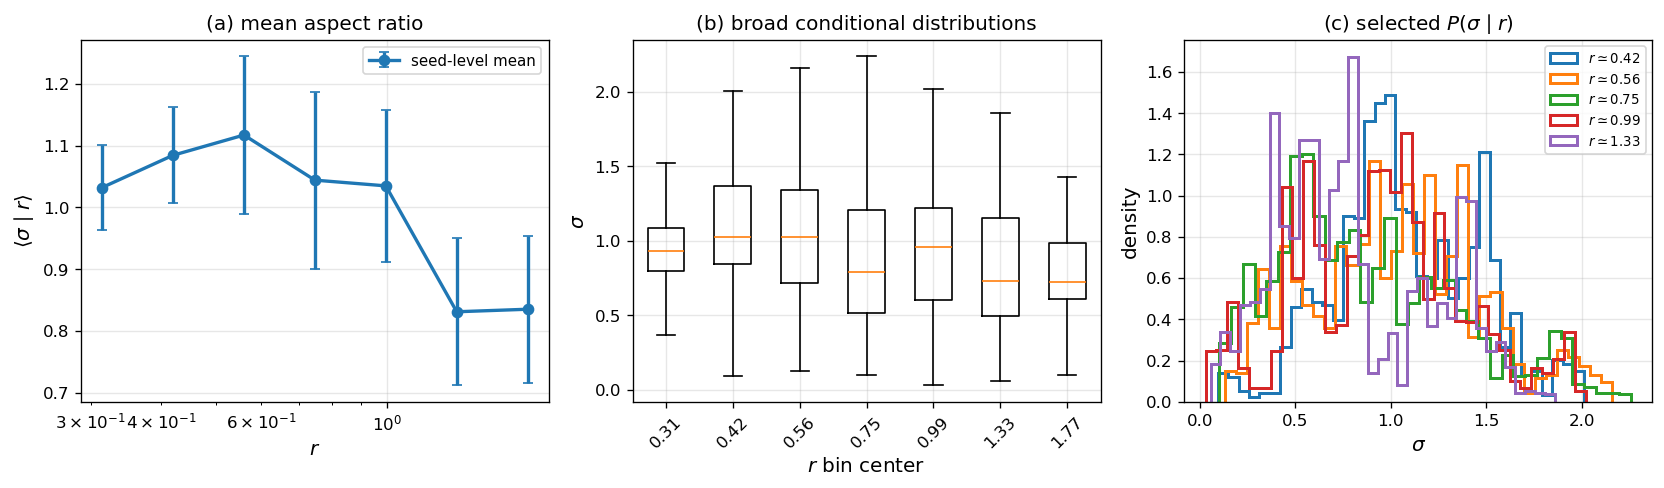

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.2))
ax = axes[0]
ax.errorbar(r_centers, sigma_mean, yerr=sigma_sem, marker='o', capsize=3, label='seed-level mean')
ax.set_xscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel(r'$\langle \sigma\mid r\rangle$'); ax.set_title('(a) mean aspect ratio'); ax.legend()
ax = axes[1]
data_box = [flat_by_bin(sigma, k=k) for k in range(n_bins)]
positions = np.arange(n_bins)
ax.boxplot(data_box, positions=positions, widths=0.55, showfliers=False)
ax.set_xticks(positions); ax.set_xticklabels([f"{x:.2f}" for x in r_centers], rotation=45)
ax.set_xlabel('$r$ bin center'); ax.set_ylabel(r'$\sigma$'); ax.set_title('(b) broad conditional distributions')
ax = axes[2]
for k in [1,2,3,4,5]:
    vals = flat_by_bin(sigma, k=k)
    if len(vals)>0:
        ax.hist(vals, bins=35, density=True, histtype='step', linewidth=1.8, label=fr'$r\simeq {r_centers[k]:.2f}$')
ax.set_xlabel(r'$\sigma$'); ax.set_ylabel('density'); ax.set_title('(c) selected $P(\sigma\mid r)$'); ax.legend(fontsize=8)
fig.tight_layout(); savefig('fig02_shape_statistics'); plt.show()


## 4. Figure 3: coarse-grained gradient statistics

This figure documents the ellipsoid-averaged gradient statistics. The tensor-level strain--vorticity ratio is

$$
\chi(r)=\frac{\operatorname{Var}(\omega\mid r)}{\operatorname{Var}(s_+\mid r)+\operatorname{Var}(s_\times\mid r)}.
$$

The baseline value for ordinary two-dimensional incompressible tensor balance is $\chi=1$.


saved /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/figures_paper/fig03_gradient_statistics.png
saved /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/figures_paper/fig03_gradient_statistics.pdf


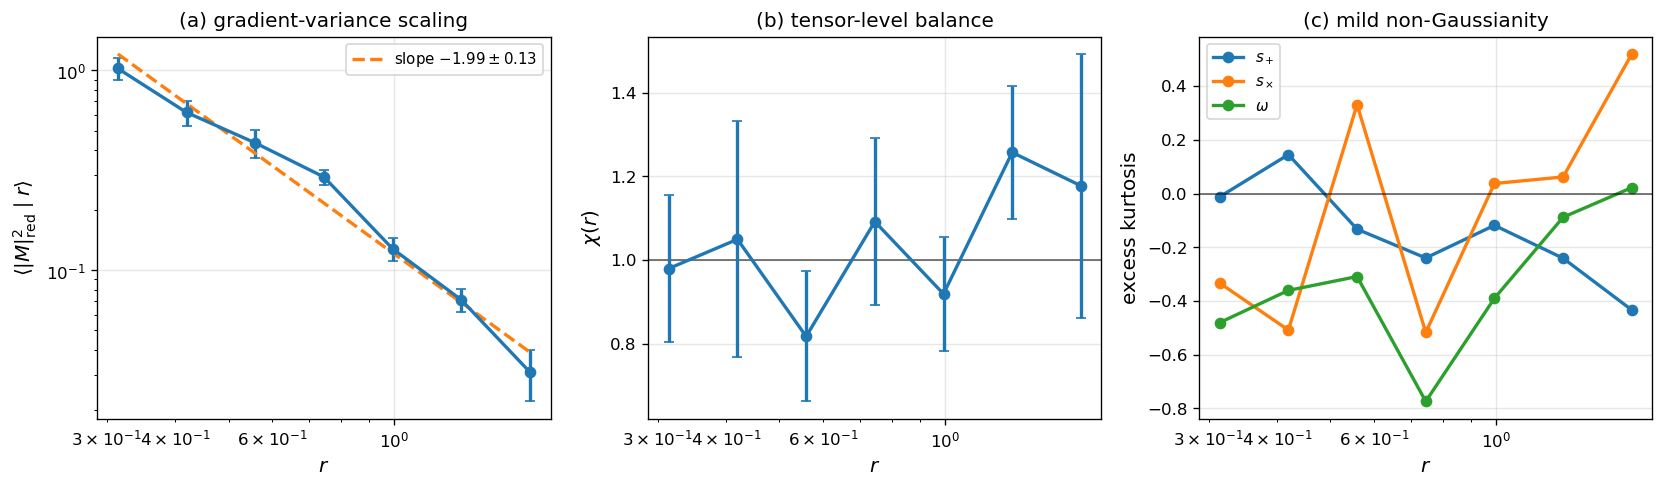

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.2))
ax = axes[0]
ax.errorbar(r_centers, M2_mean, yerr=M2_sem, marker='o', capsize=3)
xx = np.linspace(r_centers.min(), r_centers.max(), 200); yy = np.exp(intercept_M2) * xx**slope_M2
ax.plot(xx, yy, '--', label=fr'slope ${slope_M2:.2f}\pm {slope_M2_se:.2f}$')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel(r'$\langle |M|_{\rm red}^2\mid r\rangle$'); ax.set_title('(a) gradient-variance scaling'); ax.legend()
ax = axes[1]
ax.axhline(1.0, color='k', lw=1.0, alpha=0.6)
ax.errorbar(r_centers, chi, yerr=chi_sem, marker='o', capsize=3)
ax.set_xscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel(r'$\chi(r)$'); ax.set_title('(b) tensor-level balance')
ax = axes[2]
rescale = r**(2/3)
components = {'$s_+$': s_plus*rescale, r'$s_\times$': s_cross*rescale, r'$\omega$': omega*rescale}
for label, arr in components.items():
    kurts=[]
    for k in range(n_bins):
        vals=flat_by_bin(arr,k=k)
        if len(vals)>10:
            mu=np.mean(vals); sd=np.std(vals)
            kurts.append(np.mean(((vals-mu)/sd)**4)-3 if sd>0 else np.nan)
        else: kurts.append(np.nan)
    ax.plot(r_centers, kurts, marker='o', label=label)
ax.axhline(0.0, color='k', lw=1.0, alpha=0.6)
ax.set_xscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel('excess kurtosis'); ax.set_title('(c) mild non-Gaussianity'); ax.legend()
fig.tight_layout(); savefig('fig03_gradient_statistics'); plt.show()


## 5. Figure 4: source--sink decomposition

The empirical budget is

$$
\dot\sigma=2A\cos\alpha+R_\sigma.
$$

The aligned-strain source is positive over most bins. The residual $R_\sigma$ is negative and represents the effective Löwner--John projection correction. Their near-cancellation explains why the aspect ratio remains $O(1)$.


saved /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/figures_paper/fig04_source_sink_budget.png
saved /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/figures_paper/fig04_source_sink_budget.pdf


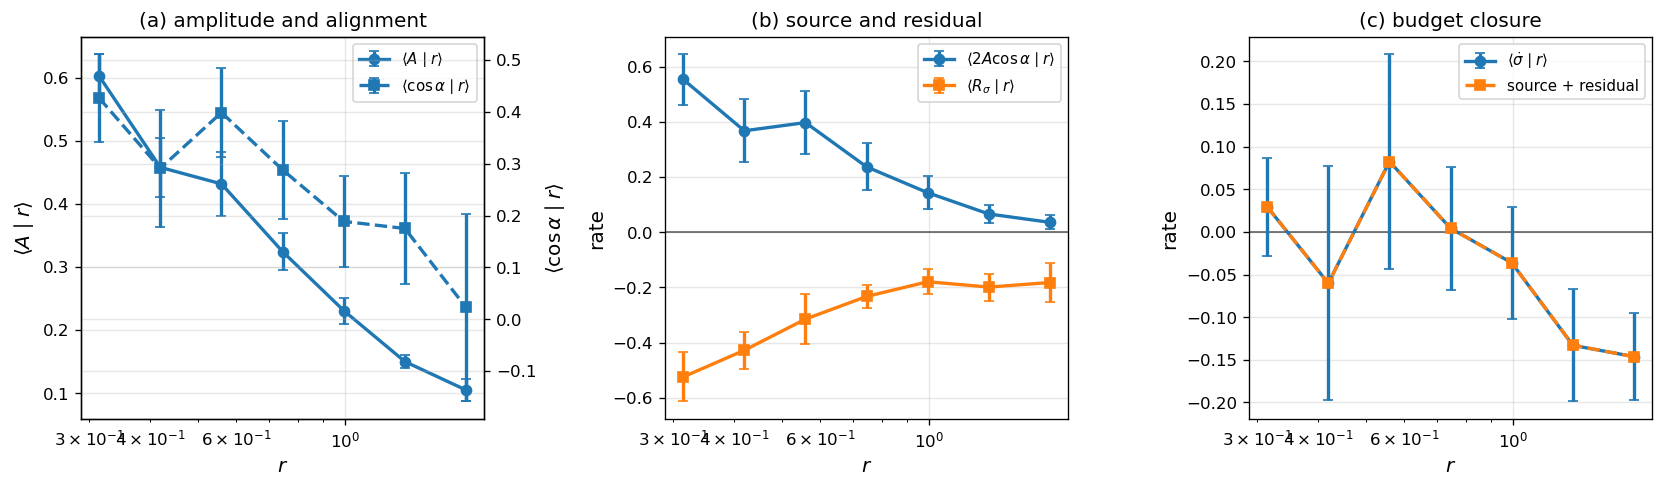

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.2))
ax=axes[0]
ax.errorbar(r_centers,A_mean,yerr=A_sem,marker='o',capsize=3,label=r'$\langle A\mid r\rangle$')
ax2=ax.twinx(); ax2.errorbar(r_centers,cos_mean,yerr=cos_sem,marker='s',capsize=3,linestyle='--',label=r'$\langle\cos\alpha\mid r\rangle$')
ax.set_xscale('log'); ax2.set_xscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel(r'$\langle A\mid r\rangle$'); ax2.set_ylabel(r'$\langle\cos\alpha\mid r\rangle$'); ax.set_title('(a) amplitude and alignment')
lines,labels=ax.get_legend_handles_labels(); lines2,labels2=ax2.get_legend_handles_labels(); ax.legend(lines+lines2,labels+labels2,loc='upper right')
ax=axes[1]
ax.axhline(0.0,color='k',lw=1.0,alpha=0.6)
ax.errorbar(r_centers,source_mean,yerr=source_sem,marker='o',capsize=3,label=r'$\langle 2A\cos\alpha\mid r\rangle$')
ax.errorbar(r_centers,R_mean,yerr=R_sem,marker='s',capsize=3,label=r'$\langle R_\sigma\mid r\rangle$')
ax.set_xscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel('rate'); ax.set_title('(b) source and residual'); ax.legend()
ax=axes[2]
ax.axhline(0.0,color='k',lw=1.0,alpha=0.6)
ax.errorbar(r_centers,dsigma_mean,yerr=dsigma_sem,marker='o',capsize=3,label=r'$\langle\dot\sigma\mid r\rangle$')
ax.errorbar(r_centers,source_mean+R_mean,yerr=None,marker='s',linestyle='--',label='source + residual')
ax.set_xscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel('rate'); ax.set_title('(c) budget closure'); ax.legend()
fig.tight_layout(); savefig('fig04_source_sink_budget'); plt.show()


## 6. Figure 5: null-model failure

-- This figure does not enter final paper, but kept here for completness.

The marginal-gradient null model treats the coarse-grained gradient as an approximately scale-dependent stochastic driver without preserving its alignment with $g$. It fails because it removes the source $2A\cos\alpha$ needed to sustain the observed aspect ratio.


saved /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/figures_paper/fig05_null_model_failure.png
saved /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/figures_paper/fig05_null_model_failure.pdf


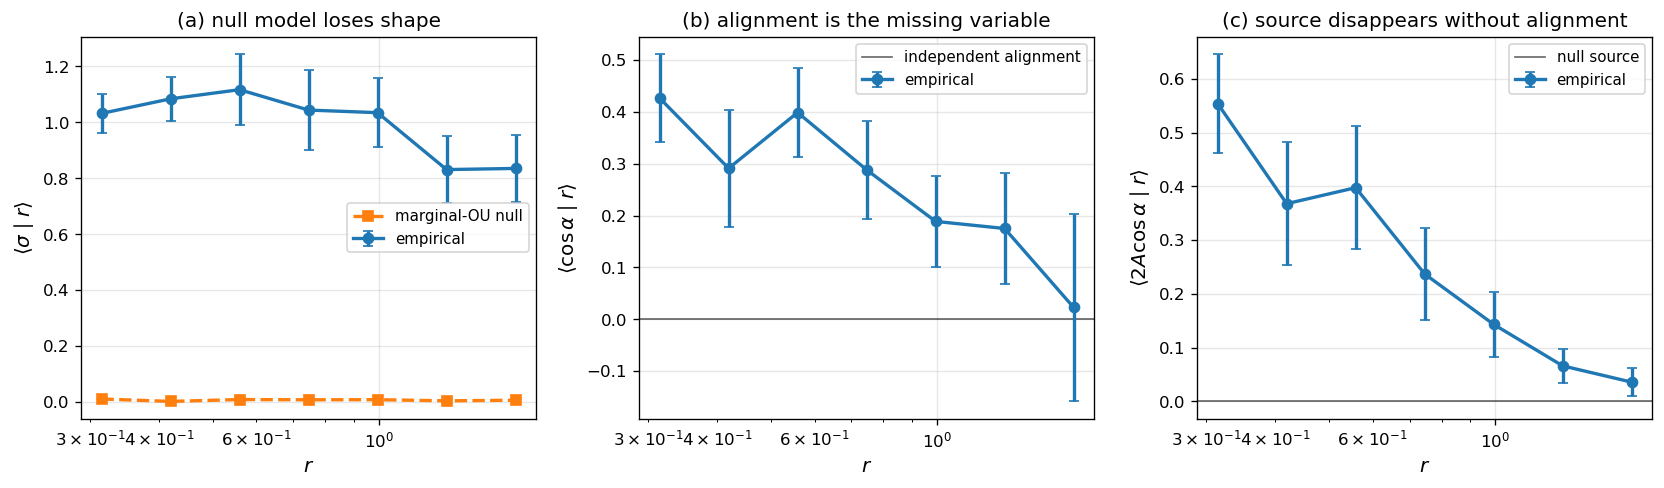

In [8]:

M0_sigma = null_npz['M0_sigma_mean'] if null_npz is not None and 'M0_sigma_mean' in null_npz.files else np.zeros_like(r_centers)
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.2))
ax=axes[0]
ax.errorbar(r_centers,sigma_mean,yerr=sigma_sem,marker='o',capsize=3,label='empirical')
ax.plot(r_centers,M0_sigma,'s--',label='marginal-OU null')
ax.set_xscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel(r'$\langle\sigma\mid r\rangle$'); ax.set_title('(a) null model loses shape'); ax.legend()
ax=axes[1]
ax.axhline(0.0,color='k',lw=1.0,alpha=0.6,label='independent alignment')
ax.errorbar(r_centers,cos_mean,yerr=cos_sem,marker='o',capsize=3,label='empirical')
ax.set_xscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel(r'$\langle\cos\alpha\mid r\rangle$'); ax.set_title('(b) alignment is the missing variable'); ax.legend()
ax=axes[2]
ax.axhline(0.0,color='k',lw=1.0,alpha=0.6,label='null source')
ax.errorbar(r_centers,source_mean,yerr=source_sem,marker='o',capsize=3,label='empirical')
ax.set_xscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel(r'$\langle 2A\cos\alpha\mid r\rangle$'); ax.set_title('(c) source disappears without alignment'); ax.legend()
fig.tight_layout(); savefig('fig05_null_model_failure'); plt.show()


## 7. Figure 6: final physics-informed closure

The final closure keeps the stationary von--Mises alignment model and compares residual closures for $R_\sigma$. The preferred interpretable closure is VM1:

$$
R_\sigma=a_0(r)+a_1(r)\sigma.
$$

This is compared against the empirical train, the marginal-OU null model, and the more restrictive VM0 residual.


saved /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/figures_paper/fig06_final_closure_validation.png
saved /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/figures_paper/fig06_final_closure_validation.pdf


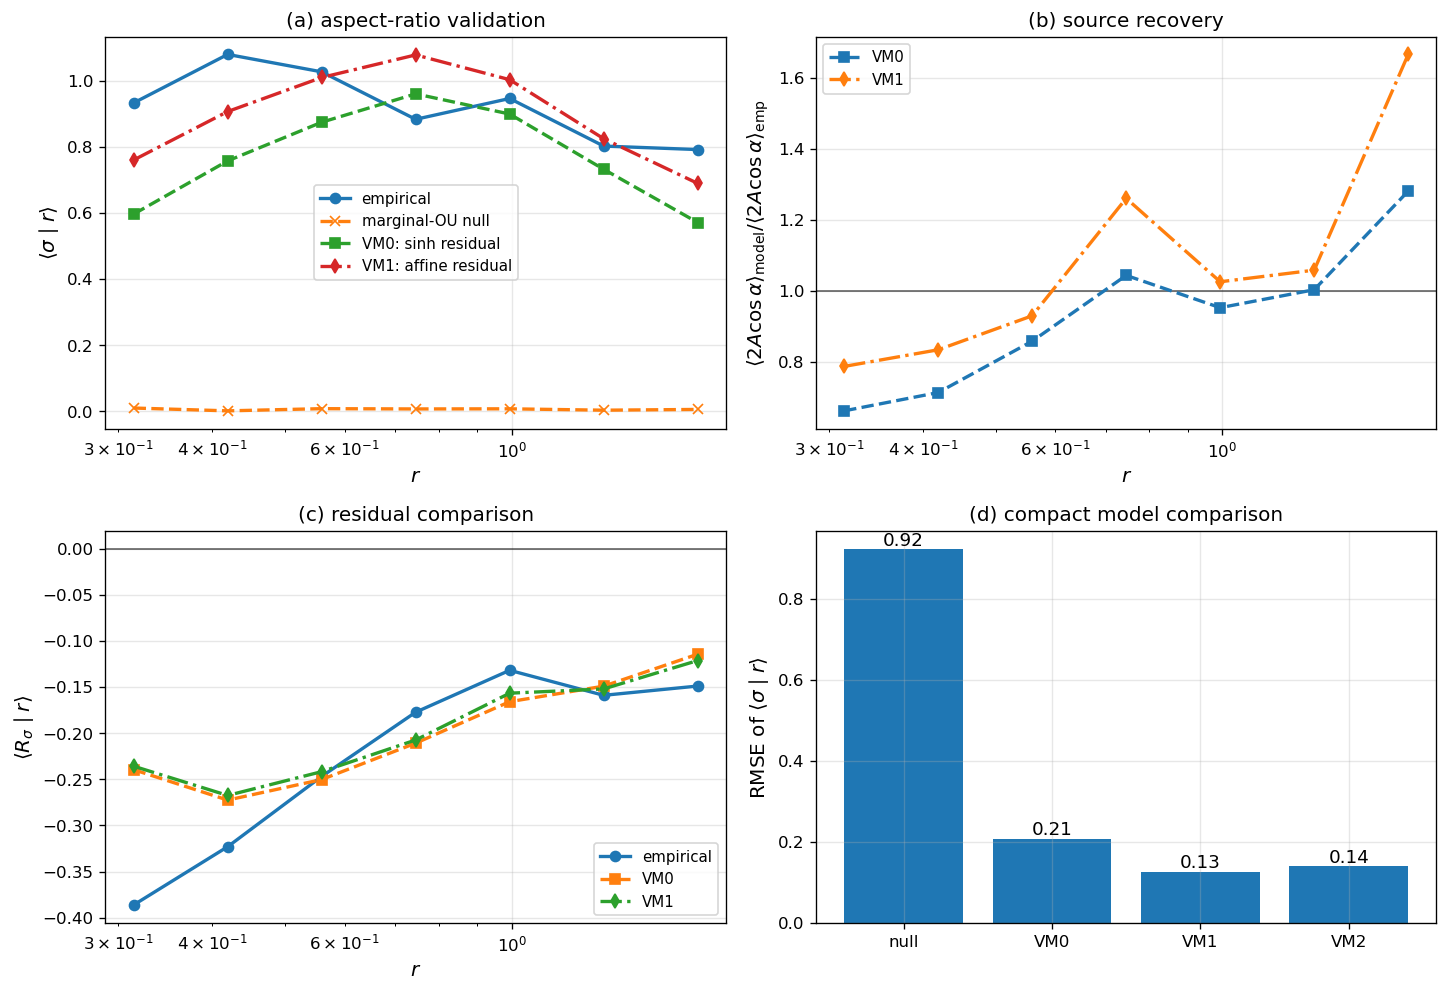

sigma RMSE: {'null': 0.9220073020460703, 'VM0': 0.20753217125321785, 'VM1': 0.1264794809055309, 'VM2': 0.13928715506443426}


In [9]:

if v15_npz is None:
    raise FileNotFoundError('Figure 6 requires sigma_residual_closure_v15_results.npz')
rc = v15_npz['r_centers']; emp_sig15 = v15_npz['emp_sigma']; emp_src15 = v15_npz['emp_source']; emp_R15 = v15_npz['emp_R_sigma']
VM0_sig = v15_npz['VM0_sigma']; VM1_sig = v15_npz['VM1_sigma']; VM2_sig = v15_npz['VM2_sigma']
VM0_src = v15_npz['VM0_source']; VM1_src = v15_npz['VM1_source']; VM0_R = v15_npz['VM0_R']; VM1_R = v15_npz['VM1_R']
M0_sig_for_v15 = np.interp(rc, r_centers, M0_sigma)
fig, axes = plt.subplots(2, 2, figsize=(12.2, 8.4))
ax=axes[0,0]
ax.plot(rc,emp_sig15,'o-',label='empirical'); ax.plot(rc,M0_sig_for_v15,'x--',label='marginal-OU null'); ax.plot(rc,VM0_sig,'s--',label='VM0: sinh residual'); ax.plot(rc,VM1_sig,'d-.',label='VM1: affine residual')
ax.set_xscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel(r'$\langle\sigma\mid r\rangle$'); ax.set_title('(a) aspect-ratio validation'); ax.legend()
ax=axes[0,1]
ax.axhline(1.0,color='k',lw=1.0,alpha=0.6); ax.plot(rc,VM0_src/np.maximum(emp_src15,1e-12),'s--',label='VM0'); ax.plot(rc,VM1_src/np.maximum(emp_src15,1e-12),'d-.',label='VM1')
ax.set_xscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel(r'$\langle 2A\cos\alpha\rangle_{\rm model}/\langle 2A\cos\alpha\rangle_{\rm emp}$'); ax.set_title('(b) source recovery'); ax.legend()
ax=axes[1,0]
ax.axhline(0.0,color='k',lw=1.0,alpha=0.6); ax.plot(rc,emp_R15,'o-',label='empirical'); ax.plot(rc,VM0_R,'s--',label='VM0'); ax.plot(rc,VM1_R,'d-.',label='VM1')
ax.set_xscale('log'); ax.set_xlabel('$r$'); ax.set_ylabel(r'$\langle R_\sigma\mid r\rangle$'); ax.set_title('(c) residual comparison'); ax.legend()
ax=axes[1,1]
models={'null':M0_sig_for_v15,'VM0':VM0_sig,'VM1':VM1_sig,'VM2':VM2_sig}
rmse_vals={name:np.sqrt(np.nanmean((arr-emp_sig15)**2)) for name,arr in models.items()}
labels=list(rmse_vals.keys()); vals=[rmse_vals[k] for k in labels]
ax.bar(labels,vals); ax.set_ylabel(r'RMSE of $\langle\sigma\mid r\rangle$'); ax.set_title('(d) compact model comparison')
for i,vv in enumerate(vals): ax.text(i,vv,f'{vv:.2f}',ha='center',va='bottom')
fig.tight_layout(); savefig('fig06_final_closure_validation'); plt.show(); print('sigma RMSE:',rmse_vals)


## 8. Export summary tables and draft captions

The following cells write simple CSV/Markdown files that can be copied into the manuscript workflow.


In [10]:

summary_rows=[]
for k in range(n_bins):
    summary_rows.append({'r_center':float(r_centers[k]),'count':int(counts[k]),'sigma_mean':float(sigma_mean[k]),'sigma_sem_seed':float(sigma_sem[k]),'M2_red_mean':float(M2_mean[k]),'chi':float(chi[k]),'A_mean':float(A_mean[k]),'cos_alpha_mean':float(cos_mean[k]),'source_mean':float(source_mean[k]),'R_sigma_mean':float(R_mean[k]),'dot_sigma_mean':float(dsigma_mean[k])})
csv_path=TAB_DIR/'empirical_bin_summary.csv'
with open(csv_path,'w',newline='') as f:
    writer=csv.DictWriter(f,fieldnames=list(summary_rows[0].keys())); writer.writeheader(); writer.writerows(summary_rows)
print('saved',csv_path)
if v15_npz is not None:
    model_rows=[]
    for name,arr in models.items(): model_rows.append({'model':name,'sigma_mean_RMSE':float(np.sqrt(np.nanmean((arr-emp_sig15)**2)))})
    csv_path2=TAB_DIR/'model_comparison_summary.csv'
    with open(csv_path2,'w',newline='') as f:
        writer=csv.DictWriter(f,fieldnames=list(model_rows[0].keys())); writer.writeheader(); writer.writerows(model_rows)
    print('saved',csv_path2)


saved /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/tables_paper/empirical_bin_summary.csv
saved /Users/chertkov/Dropbox/Apps/Overleaf/PathIntegralTetradDiffusion/experiments/final-github-notebook/tables_paper/model_comparison_summary.csv


## 19. Checklist for manuscript use

Recommended main-paper figures:

1. `fig02_shape_statistics`
2. `fig03_gradient_statistics`
3. `fig04_source_sink_budget`
4. `fig05_null_model_failure` (this figure does not enter final paper, but kept here for completness)
5. `fig06_final_closure_validation`

The notebook also writes:

- `tables_paper/empirical_bin_summary.csv`
- `tables_paper/model_comparison_summary.csv`
- `paper_figure_captions.md`

For the paper, the main text should emphasize the sequence: